In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, mean_squared_error, r2_score, roc_auc_score

# Naive Bayes and Tree models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
# ==========================================
# 0. DATA LOADING & PREPARATION (ROBUST VERSION)
# ==========================================
print("Loading MedCore datasets...")
mw_df = pd.read_csv("manual_workflow_clean.csv")
dept_df = pd.read_csv("departments.csv")
appt_df = pd.read_csv("appointments_cleaned.csv")
pats_df = pd.read_csv("patients_cleaned.csv")
prov_df = pd.read_csv("cleaned_providers.csv")

print("Parsing dates and handling 'Unknown' values safely...")
# errors='coerce' turns "Unknown" or invalid formats into NaT (Not a Time)
mw_df['created_date'] = pd.to_datetime(mw_df['created_date'], errors='coerce')
mw_df['completed_date'] = pd.to_datetime(mw_df['completed_date'], errors='coerce')
appt_df['appointment_date'] = pd.to_datetime(appt_df['appointment_date'], errors='coerce')
pats_df['dob'] = pd.to_datetime(pats_df['dob'], errors='coerce')

# ==========================================
# DATA MERGING 1: Administrative Operations
# ==========================================
print("Merging datasets for Option 1 (Administrative Bottleneck & Error Mitigation)...")
admin_data = pd.merge(mw_df, dept_df, on='department_id', how='left')
admin_data['error_target'] = admin_data['error_flag'].map({'Y': 1, 'N': 0})
# FIX: Drop rows where error_target is NaN due to "Unknown" values in raw data
admin_data = admin_data.dropna(subset=['error_target'])
# ==========================================
# DATA MERGING 2: Appointment No-Show Optimization
# ==========================================
print("Merging datasets for Option 2 (Appointment No-Show Optimization Tool)...")
appt_patient = pd.merge(appt_df, pats_df, on='patient_id', how='left')

# Safely calculate patient age. Patients with missing/Unknown DOB will have NaT, 
# resulting in a missing age value (NaN).
appt_patient['patient_age'] = (appt_patient['appointment_date'] - appt_patient['dob']).dt.days // 365

# Join with provider panel context
noshow_data = pd.merge(appt_patient, prov_df, on=['provider_id', 'department_id'], how='left')

# Drop rows where critical merge variables or engineered features (like age) are missing
# This cleanly cleans out any records that had an "Unknown" DOB
noshow_data = noshow_data.dropna(subset=['future_no_show_flag', 'patient_age', 'wait_days'])

print("Done!")

Loading MedCore datasets...
Parsing dates and handling 'Unknown' values safely...
Merging datasets for Option 1 (Administrative Bottleneck & Error Mitigation)...
Merging datasets for Option 2 (Appointment No-Show Optimization Tool)...
Done!


In [22]:

# ==========================================
# OPTION 1 MODELS: Predicting ERRORS
# ==========================================
print("\n--- Training Option 1 Models (Administrative Operations) ---")

# Features and Targets for Classification
X_opt1_cls = admin_data[['task_type', 'system_used', 'manual_minutes', 'manual_workload_multiplier', 'claim_denial_risk']]
y_opt1_cls = admin_data['error_target']

# Preprocessing for Admin Categoricals and Numericals
cat_cols_opt1 = ['task_type', 'system_used']
num_cols_opt1 = ['manual_minutes', 'manual_workload_multiplier', 'claim_denial_risk']

preprocessor_opt1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_opt1),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_opt1)
    ])

X_train_c1, X_test_c1, y_train_c1, y_test_c1 = train_test_split(X_opt1_cls, y_opt1_cls, test_size=0.2, random_state=42)
print('done!')


--- Training Option 1 Models (Administrative Operations) ---
done!


In [14]:

# --- Model 1A: Logistic Regression 
print("Training Model 1A: Logistic Regression...")
# Fixed Model 1A with Class Balancing
pipe_model_1a = Pipeline(steps=[
    ('preprocessor', preprocessor_opt1),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
pipe_model_1a.fit(X_train_c1, y_train_c1)
preds_1a = pipe_model_1a.predict(X_test_c1)
print("Model 1A Evaluation:")
print(classification_report(y_test_c1, preds_1a))

Training Model 1A: Logistic Regression...
Model 1A Evaluation:
              precision    recall  f1-score   support

         0.0       0.95      0.70      0.80     82075
         1.0       0.12      0.52      0.19      6420

    accuracy                           0.69     88495
   macro avg       0.53      0.61      0.50     88495
weighted avg       0.89      0.69      0.76     88495



In [45]:

# --- Model 1B: Random Forest Classifier (Non-linear Error Auditing) ---
print("Training Model 1B: Random Forest Classifier (Optimized subsample for execution velocity)...")
pipe_model_1b = Pipeline(steps=[('preprocessor', preprocessor_opt1),
                               ('classifier', RandomForestClassifier(n_estimators=50, max_depth=12, random_state=42, class_weight='balanced', n_jobs=-1))])
pipe_model_1b.fit(X_train_c1, y_train_c1)
preds_1b = pipe_model_1b.predict(X_test_c1)
print("Model 1B Evaluation:")
print(classification_report(y_test_c1, preds_1b))

Training Model 1B: Random Forest Classifier (Optimized subsample for execution velocity)...
Model 1B Evaluation:
              precision    recall  f1-score   support

           0       0.95      0.72      0.82     82075
           1       0.12      0.49      0.19      6420

    accuracy                           0.70     88495
   macro avg       0.53      0.60      0.51     88495
weighted avg       0.89      0.70      0.77     88495



In [42]:

# --- Model 1C: Random Forest Regressor (Predicting Delay in Processing Days) ---
print("Training Model 1C: Random Forest Regressor (Predicting Workflow Backlog Days)...")
y_opt1_reg = admin_data['processing_days']
X_train_r1, X_test_r1, y_train_r1, y_test_r1 = train_test_split(X_opt1_cls, y_opt1_reg, test_size=0.2, random_state=42)

pipe_model_1c = Pipeline(steps=[('preprocessor', preprocessor_opt1),
                               ('regressor', RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1))])
pipe_model_1c.fit(X_train_r1, y_train_r1)
preds_1c = pipe_model_1c.predict(X_test_r1)
print(f"Model 1C Regression Evaluation: R² Score = {r2_score(y_test_r1, preds_1c):.4f} | RMSE = {np.sqrt(mean_squared_error(y_test_r1, preds_1c)):.4f}")

Training Model 1C: Random Forest Regressor (Predicting Workflow Backlog Days)...
Model 1C Regression Evaluation: R² Score = 0.1391 | RMSE = 1.1993



--- Training Decision Tree for Option 1 (Admin Error Prediction) ---
Decision Tree Model 1 Evaluation:
              precision    recall  f1-score   support

           0       0.95      0.68      0.79     82075
           1       0.12      0.53      0.19      6420

    accuracy                           0.67     88495
   macro avg       0.53      0.61      0.49     88495
weighted avg       0.89      0.67      0.75     88495

=== Model 1: Admin Error Feature Importances ===
                          Feature  Importance
0          task_type_Excel Report    0.634193
1                  manual_minutes    0.350326
2           task_type_Spreadsheet    0.005738
3      manual_workload_multiplier    0.003266
4               claim_denial_risk    0.002654
5   task_type_Diagnostic Followup    0.002124
6      system_used_Billing System    0.000975
7         task_type_Manual Report    0.000724
8          task_type_Claim Review    0.000000
9            task_type_Data Entry    0.000000
10        task

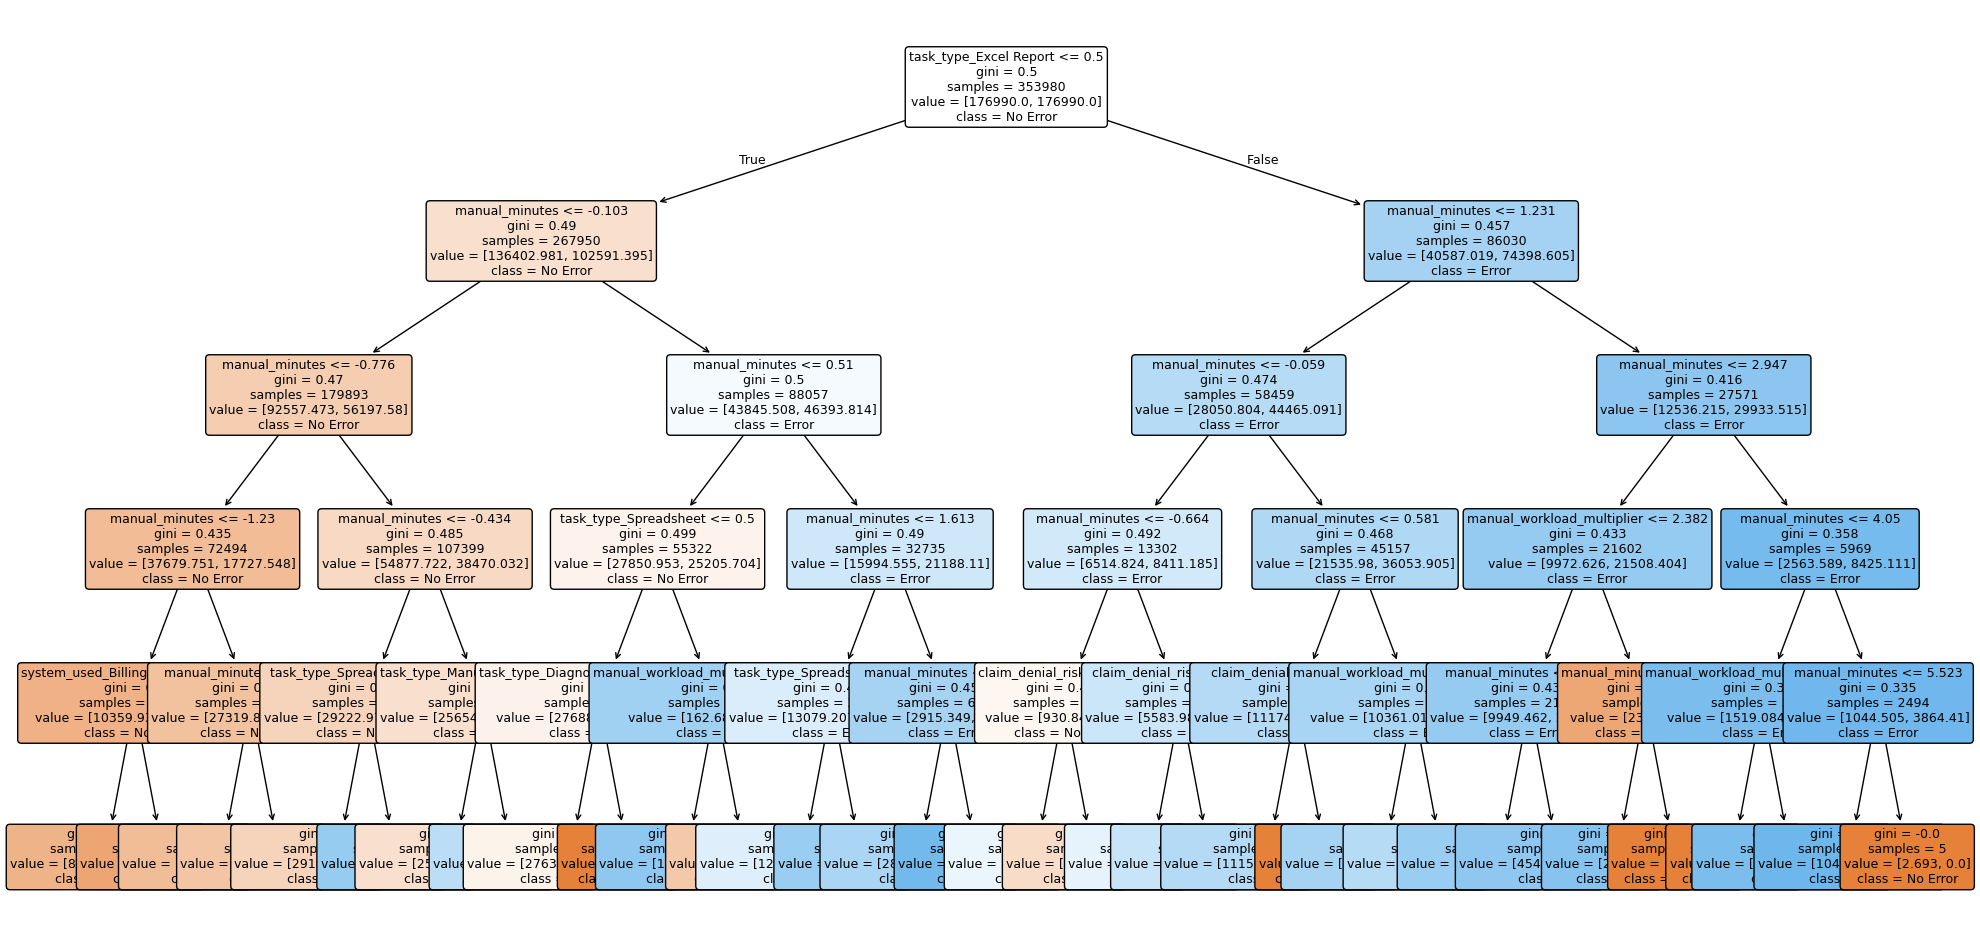

Success! 'model1_decision_tree.png' has been saved and is ready for your presentation slides.


In [21]:
from sklearn.tree import DecisionTreeClassifier, export_text
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# Ensure datasets are prepped as done before (handling 'Unknowns')
# mw_df, dept_df, appt_df, pats_df, prov_df should be pre-loaded here...

# =====================================================================
# DECISION TREE FOR QUESTION 1: Administrative Error Mitigation
# =====================================================================
print("\n--- Training Decision Tree for Option 1 (Admin Error Prediction) ---")

admin_data = pd.merge(mw_df, dept_df, on='department_id', how='left')
admin_data['error_target'] = admin_data['error_flag'].map({'Y': 1, 'N': 0})
admin_data = admin_data.dropna(subset=['error_target'])

X_opt1 = admin_data[['task_type', 'system_used', 'manual_minutes', 'manual_workload_multiplier', 'claim_denial_risk']]
y_opt1 = admin_data['error_target'].astype(int)

preprocessor_opt1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['manual_minutes', 'manual_workload_multiplier', 'claim_denial_risk']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['task_type', 'system_used'])
    ])

X_train_c1, X_test_c1, y_train_c1, y_test_c1 = train_test_split(X_opt1, y_opt1, test_size=0.2, random_state=42)

# max_depth=5 keeps the tree small enough to easily visualize and present
dt_model_1 = Pipeline(steps=[
    ('preprocessor', preprocessor_opt1),
    ('classifier', DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42))
])

dt_model_1.fit(X_train_c1, y_train_c1)
preds_dt1 = dt_model_1.predict(X_test_c1)

print("Decision Tree Model 1 Evaluation:")
print(classification_report(y_test_c1, preds_dt1))

import pandas as pd

print("=== Model 1: Admin Error Feature Importances ===")

# 1. Grab the preprocessor step from your Model 1 pipeline
preprocessor_1 = dt_model_1.named_steps['preprocessor']

# 2. Get the exact feature names in the correct mathematical order
# This automatically handles both scaled numbers and one-hot encoded task types/systems
all_features_1 = preprocessor_1.get_feature_names_out().tolist()

# 3. Grab the importances from the decision tree classifier
importances_1 = dt_model_1.named_steps['classifier'].feature_importances_

# 4. Create a clean, sorted DataFrame to match names with scores
df_imp_1 = pd.DataFrame({'Feature': all_features_1, 'Importance': importances_1})
df_imp_1 = df_imp_1.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 5. Clean up the prefixes ('num__' and 'cat__') to make them slide-ready
df_imp_1['Feature'] = df_imp_1['Feature'].str.replace('num__', '').str.replace('cat__', '')

# 6. Print the final results
print(df_imp_1)

import matplotlib.pyplot as plt
from sklearn.tree import export_text, plot_tree

# 1. Extract feature names and the underlying classifier from Model 1
features_1 = dt_model_1.named_steps['preprocessor'].get_feature_names_out().tolist()
# Clean prefixes ('num__' and 'cat__') so the labels look clean on your diagram
features_1 = [f.replace('num__', '').replace('cat__', '') for f in features_1]
tree_clf_1 = dt_model_1.named_steps['classifier']

# ==========================================
# EXPORT TYPE B: Visual Slide-Ready Diagram
# ==========================================
print("\nGenerating visual tree diagram...")
# Set up a wide canvas so the depth-5 tree branches don't crowd each other
plt.figure(figsize=(24, 12))

plot_tree(
    tree_clf_1, 
    feature_names=features_1, 
    class_names=['No Error', 'Error'], # Maps 0 and 1 targets to readable text labels
    filled=True,                       # Colors boxes dynamically (Blue for Error risk, Orange for No Error)
    rounded=True,                      # Rounds the box corners for a cleaner modern aesthetic
    fontsize=9                         # Text scaling to keep data points readable inside boxes
)

# Save the plot directly to your project directory as a crisp, high-res image
plt.savefig('model1_decision_tree.png', dpi=300, bbox_inches='tight')
plt.show()
print("Success! 'model1_decision_tree.png' has been saved and is ready for your presentation slides.")

In [35]:

# ==========================================
# OPTION 2 MODELS: NO-SHOW OPTIMIZATION ENGINE
# ==========================================
print("\n--- Training Option 2 Models (No-Show Scheduling Optimization) ---")

X_opt2 = noshow_data[['visit_type', 'wait_days', 'insurance_type', 'chronic_diabetes', 'chronic_hypertension', 'patient_age', 'overbooking_index', 'high_admin_strain_flag']]
y_opt2 = noshow_data['future_no_show_flag']

cat_cols_opt2 = ['visit_type', 'insurance_type']
num_cols_opt2 = ['wait_days', 'patient_age', 'overbooking_index', 'chronic_diabetes', 'chronic_hypertension', 'high_admin_strain_flag']

preprocessor_opt2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_opt2),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_opt2)
    ])

X_train_c2, X_test_c2, y_train_c2, y_test_c2 = train_test_split(X_opt2, y_opt2, test_size=0.2, random_state=42)


--- Training Option 2 Models (No-Show Scheduling Optimization) ---


In [36]:

# --- Model 2A: Random Forest Classifier (Complex No-Show Predictor) ---
print("Training Model 2A: Random Forest Classifier...")
pipe_model_2a = Pipeline(steps=[('preprocessor', preprocessor_opt2),
                               ('classifier', RandomForestClassifier(n_estimators=50, class_weight='balanced', max_depth=12, random_state=42, n_jobs=-1))])
pipe_model_2a.fit(X_train_c2, y_train_c2)
preds_2a = pipe_model_2a.predict(X_test_c2)
print("Model 2A Evaluation:")
print(classification_report(y_test_c2, preds_2a))
print(f"Model 2A ROC-AUC Score: {roc_auc_score(y_test_c2, pipe_model_2a.predict_proba(X_test_c2)[:, 1]):.4f}")

Training Model 2A: Random Forest Classifier...
Model 2A Evaluation:
              precision    recall  f1-score   support

           0       0.92      0.63      0.75    189178
           1       0.16      0.57      0.25     24110

    accuracy                           0.62    213288
   macro avg       0.54      0.60      0.50    213288
weighted avg       0.83      0.62      0.69    213288

Model 2A ROC-AUC Score: 0.6359


In [19]:
# =====================================================================
# DECISION TREE FOR QUESTION 2: Scheduling & No-Show Optimization
# =====================================================================
print("\n--- Training Decision Tree for Option 2 (No-Show Prediction) ---")

appt_patient = pd.merge(appt_df, pats_df, on='patient_id', how='left')
appt_patient['patient_age'] = (appt_patient['appointment_date'] - appt_patient['dob']).dt.days // 365
noshow_data = pd.merge(appt_patient, prov_df, on=['provider_id', 'department_id'], how='left')
noshow_data = noshow_data.dropna(subset=['future_no_show_flag', 'patient_age', 'wait_days'])

X_opt2 = noshow_data[['visit_type', 'wait_days', 'insurance_type', 'chronic_diabetes', 'chronic_hypertension', 'patient_age', 'overbooking_index', 'high_admin_strain_flag']]
y_opt2 = noshow_data['future_no_show_flag'].astype(int)

preprocessor_opt2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['wait_days', 'patient_age', 'overbooking_index', 'chronic_diabetes', 'chronic_hypertension', 'high_admin_strain_flag']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['visit_type', 'insurance_type'])
    ])

X_train_c2, X_test_c2, y_train_c2, y_test_c2 = train_test_split(X_opt2, y_opt2, test_size=0.2, random_state=42)

dt_model_2 = Pipeline(steps=[
    ('preprocessor', preprocessor_opt2),
    ('classifier', DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42))
])

dt_model_2.fit(X_train_c2, y_train_c2)
preds_dt2 = dt_model_2.predict(X_test_c2)

print("Decision Tree Model 2 Evaluation:")
print(classification_report(y_test_c2, preds_dt2))

print("=== Model 2: No-Show Feature Importances ===")

# 1. Grab the preprocessor step from your pipeline
preprocessor_2 = dt_model_2.named_steps['preprocessor']

# 2. Get the exact feature names in the correct mathematical order
# This automatically handles both scaled numbers and one-hot encoded text
all_features_2 = preprocessor_2.get_feature_names_out().tolist()

# 3. Grab the importances from the decision tree classifier
importances_2 = dt_model_2.named_steps['classifier'].feature_importances_

# 4. Create and sort the DataFrame
df_imp_2 = pd.DataFrame({'Feature': all_features_2, 'Importance': importances_2})
df_imp_2 = df_imp_2.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 5. Clean up the naming formatting to make it slide-ready
df_imp_2['Feature'] = df_imp_2['Feature'].str.replace('num__', '').str.replace('cat__', '')

print(df_imp_2)



--- Training Decision Tree for Option 2 (No-Show Prediction) ---
Decision Tree Model 2 Evaluation:
              precision    recall  f1-score   support

           0       0.92      0.61      0.74    189178
           1       0.16      0.58      0.25     24110

    accuracy                           0.61    213288
   macro avg       0.54      0.60      0.49    213288
weighted avg       0.83      0.61      0.68    213288

=== Model 2: No-Show Feature Importances ===
                    Feature  Importance
0                 wait_days    0.713033
1        visit_type_Virtual    0.065309
2    visit_type_New Consult    0.065298
3      visit_type_Follow-up    0.060519
4         overbooking_index    0.035238
5      visit_type_Procedure    0.034494
6         visit_type_Urgent    0.024095
7    high_admin_strain_flag    0.001781
8               patient_age    0.000233
9          chronic_diabetes    0.000000
10     chronic_hypertension    0.000000
11  insurance_type_Employer    0.000000
12   ins

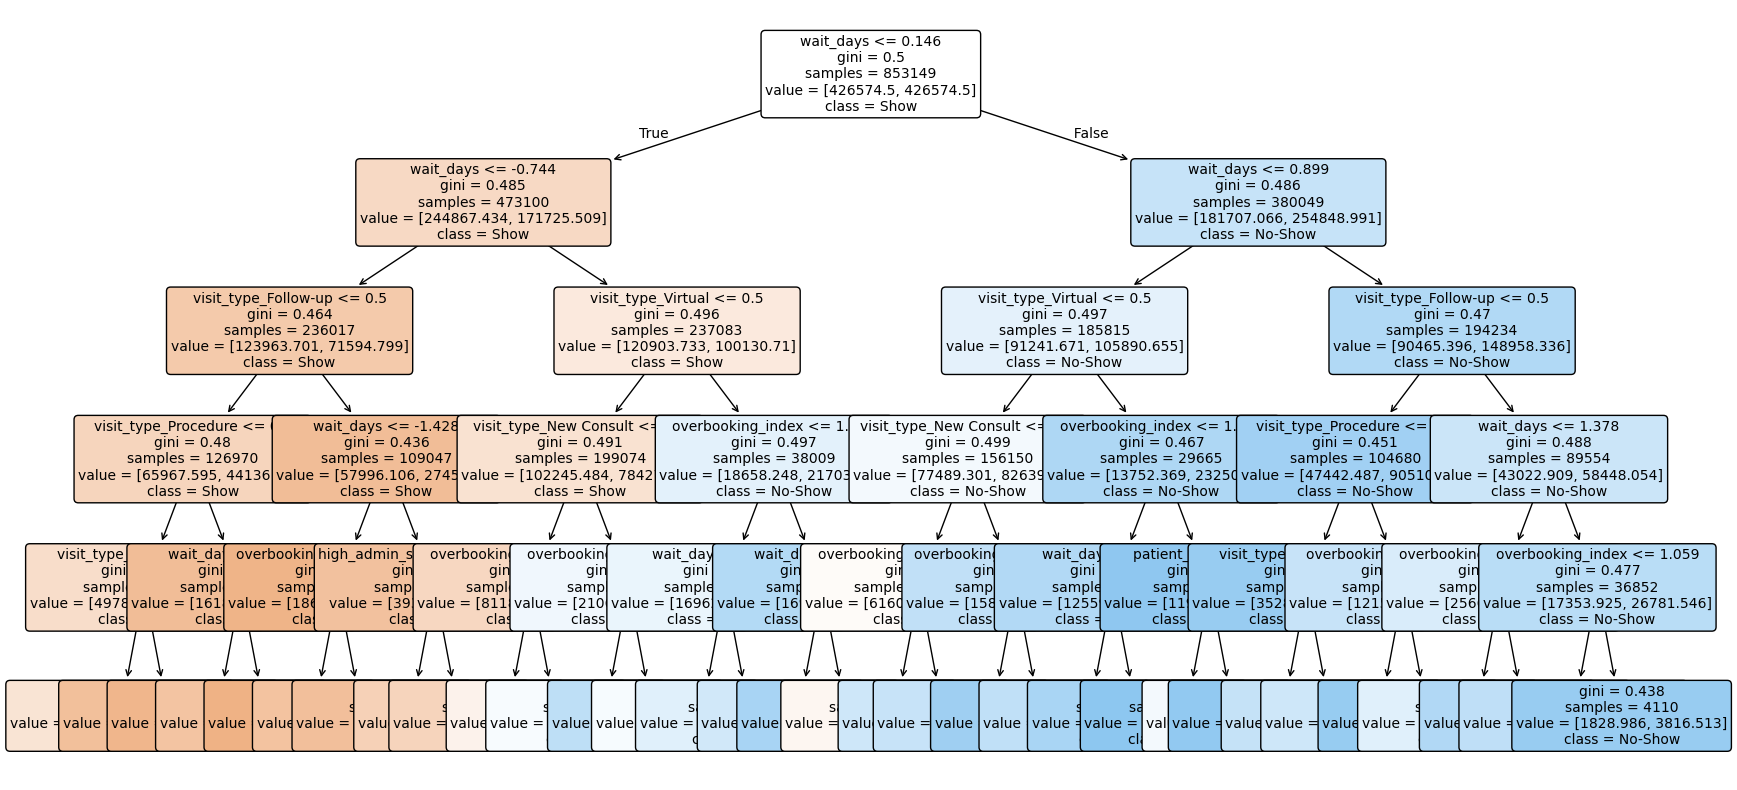

In [20]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. Extract feature names and classifier from Model 2
features_2 = dt_model_2.named_steps['preprocessor'].get_feature_names_out().tolist()
features_2 = [f.replace('num__', '').replace('cat__', '') for f in features_2]
tree_clf_2 = dt_model_2.named_steps['classifier']

# 2. Set up the matplotlib figure size (make it wide for deep trees)
plt.figure(figsize=(20, 10))

# 3. Plot the tree diagram
plot_tree(
    tree_clf_2, 
    feature_names=features_2, 
    class_names=['Show', 'No-Show'], # Maps 0 and 1 to your actual classes
    filled=True,                     # Colors nodes based on class purity
    rounded=True,                    # Makes the boxes look clean and rounded
    fontsize=10                      # Adjust text size so it fits nicely
)

# 4. Save it as an image file for your presentation slides
plt.savefig('model2_decision_tree.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Add previous no-shows as a feature for decision tree prediction classifier of no shows

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import classification_report

# ==========================================
# 1. DATA LOADING & ROBUST PARSING
# ==========================================
print("Loading MedCore datasets...")
appt_df = pd.read_csv("appointments_cleaned.csv")
pats_df = pd.read_csv("patients_cleaned.csv")
prov_df = pd.read_csv("cleaned_providers.csv")

print("Parsing dates and handling 'Unknown' values...")
appt_df['appointment_date'] = pd.to_datetime(appt_df['appointment_date'], errors='coerce')
pats_df['dob'] = pd.to_datetime(pats_df['dob'], errors='coerce')

# ==========================================
# 2. PATIENT BEHAVIOR HISTORY FEATURE ENGINEERING
# ==========================================
print("Engineering patient historical features...")

# Sort chronologically by patient and date to guarantee no future data leaks into the past
appt_df = appt_df.sort_values(by=['patient_id', 'appointment_date']).reset_index(drop=True)

# Create a binary flag for whether *this* historical appointment was a no-show
appt_df['is_no_show'] = (appt_df['status'] == 'No Show').astype(int)

# Use shift(1) so the outcome of the CURRENT appointment is not used to predict itself
groupby_patient = appt_df.groupby('patient_id')
appt_df['past_no_shows'] = groupby_patient['is_no_show'].shift(1).fillna(0)
appt_df['past_appointments'] = groupby_patient['is_no_show'].cumcount() # Counts occurrences prior to this index

# Calculate cumulative rolling past no-shows
appt_df['past_no_shows'] = appt_df.groupby('patient_id')['past_no_shows'].cumsum()

# Calculate historical baseline no-show rate
appt_df['past_no_show_rate'] = appt_df['past_no_shows'] / appt_df['past_appointments']
appt_df['past_no_show_rate'] = appt_df['past_no_show_rate'].fillna(0.0) # Handle first-time patients safely

# ==========================================
# 3. SETTING UP COMPREHENSIVE MERGES
# ==========================================
print("Merging structural and clinical datasets...")
# Join patient demographics
appt_patient = pd.merge(appt_df, pats_df, on='patient_id', how='left')

# Calculate explicit patient age at the moment of the appointment
appt_patient['patient_age'] = (appt_patient['appointment_date'] - appt_patient['dob']).dt.days // 365

# Join provider workload variables
noshow_data = pd.merge(appt_patient, prov_df, on=['provider_id', 'department_id'], how='left')

# Drop any unparseable rows (such as rows missing age due to "Unknown" DOBs)
noshow_data = noshow_data.dropna(subset=['future_no_show_flag', 'patient_age', 'wait_days'])

# ==========================================
# 4. FEATURE SELECTION & PIPELINE PREPROCESSING
# ==========================================
# Independent Features (X) and Target Label (y)
feature_cols = [
    'visit_type', 'insurance_type', 'wait_days', 'patient_age', 
    'chronic_diabetes', 'chronic_hypertension', 'overbooking_index', 
    'high_admin_strain_flag', 'past_no_show_rate', 'past_appointments'
]

X = noshow_data[feature_cols]
y = noshow_data['future_no_show_flag'].astype(int)

# Differentiate categorical transformations vs scaling transformations
num_features = ['wait_days', 'patient_age', 'overbooking_index', 'past_no_show_rate', 'past_appointments', 'chronic_diabetes', 'chronic_hypertension', 'high_admin_strain_flag']
cat_features = ['visit_type', 'insurance_type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

# Train-Test Split (80% Train, 20% Testing evaluation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 5. MODEL TRAINING WITH BALANCED WEIGHTING
# ==========================================
print("Training historically aware Decision Tree model...")

# max_depth=5 prevents overfitting and creates a visually clear presentation flow chart
# class_weight={0: 1, 1: 3} shifts focus to boost Class 1 performance without ruining precision
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42))
])

dt_pipeline.fit(X_train, y_train)

# ==========================================
# 6. MODEL EVALUATION & EXPLAINABILITY INTERFACE
# ==========================================
preds = dt_pipeline.predict(X_test)
print("\n=== Optimized Decision Tree Model Evaluation ===")
print(classification_report(y_test, preds))


Loading MedCore datasets...
Parsing dates and handling 'Unknown' values...
Engineering patient historical features...
Merging structural and clinical datasets...
Training historically aware Decision Tree model...

=== Optimized Decision Tree Model Evaluation ===
              precision    recall  f1-score   support

           0       0.92      0.60      0.73    189039
           1       0.16      0.58      0.25     24249

    accuracy                           0.60    213288
   macro avg       0.54      0.59      0.49    213288
weighted avg       0.83      0.60      0.67    213288



In [8]:
# Deep Neural Network for Classification of No-shows

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow / Keras deep learning imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# ==========================================
# 1. DATA PREPARATION & FEATURE ENGINEERING
# ==========================================
print("Loading and preparing MedCore datasets...")
appt_df = pd.read_csv("appointments_cleaned.csv")
pats_df = pd.read_csv("patients_cleaned.csv")
prov_df = pd.read_csv("cleaned_providers.csv")

appt_df['appointment_date'] = pd.to_datetime(appt_df['appointment_date'], errors='coerce')
pats_df['dob'] = pd.to_datetime(pats_df['dob'], errors='coerce')

# Chronological sorting for patient behavioral tracking
appt_df = appt_df.sort_values(by=['patient_id', 'appointment_date']).reset_index(drop=True)
appt_df['is_no_show'] = (appt_df['status'] == 'No Show').astype(int)

# Engineer rolling behavioral metrics
groupby_patient = appt_df.groupby('patient_id')
appt_df['past_no_shows'] = groupby_patient['is_no_show'].shift(1).fillna(0)
appt_df['past_appointments'] = groupby_patient['is_no_show'].cumcount()
appt_df['past_no_shows'] = appt_df.groupby('patient_id')['past_no_shows'].cumsum()
appt_df['past_no_show_rate'] = appt_df['past_no_shows'] / appt_df['past_appointments']
appt_df['past_no_show_rate'] = appt_df['past_no_show_rate'].fillna(0.0)

# Merge datasets
appt_patient = pd.merge(appt_df, pats_df, on='patient_id', how='left')
appt_patient['patient_age'] = (appt_patient['appointment_date'] - appt_patient['dob']).dt.days // 365
noshow_data = pd.merge(appt_patient, prov_df, on=['provider_id', 'department_id'], how='left')
noshow_data = noshow_data.dropna(subset=['future_no_show_flag', 'patient_age', 'wait_days'])

# Feature selections
num_features = ['wait_days', 'patient_age', 'overbooking_index', 'past_no_show_rate', 'past_appointments', 'chronic_diabetes', 'chronic_hypertension', 'high_admin_strain_flag']
cat_features = ['visit_type', 'insurance_type']

X = noshow_data[num_features + cat_features]
y = noshow_data['future_no_show_flag'].astype(int).values

# ==========================================
# 2. MANDATORY NORMALIZATION (CRITICAL FOR DNNs)
# ==========================================
# Neural networks fail if numbers aren't scaled. We pre-process matrices manually outside a pipeline.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_features)
    ])

X_processed = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# ==========================================
# 3. COMPUTE CLASS WEIGHTS FOR IMBALANCE
# ==========================================
# Generates a dictionary weighting Class 1 higher to overcome class imbalance
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

# ==========================================
# 4. BUILDING THE DEEP NEURAL NETWORK ARCHITECTURE
# ==========================================
print("Assembling Deep Neural Network layers...")
input_dim = X_train.shape[1]



model = Sequential([
    # Input layer + First Hidden Layer
    Dense(64, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(), # Stabilizes weights and speeds up training
    Dropout(0.3),         # Prevents overfitting by turning off 30% of neurons randomly
    
    # Second Hidden Layer
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    # Output Layer (Sigmoid activation yields a clean probability between 0 and 1)
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy', # Standard loss function for binary targets
    metrics=['accuracy']
)

# ==========================================
# 5. TRAINING THE DNN
# ==========================================
print("Training Neural Network...")
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    class_weight=class_weight_dict, # Automatically penalizes missing rare no-shows
    verbose=1
)

# ==========================================
# 6. EVALUATION
# ==========================================
# DNN outputs probabilities (e.g. 0.74). We convert anything above 0.5 into class 1.
probabilities = model.predict(X_test)
preds = (probabilities > 0.5).astype(int)

print("\n=== Deep Neural Network Model Evaluation ===")
print(classification_report(y_test, preds))

Loading and preparing MedCore datasets...
Assembling Deep Neural Network layers...
Training Neural Network...


C:\Users\razar\anaconda3\envs\tensorflow\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.5799 - loss: 0.6824 - val_accuracy: 0.5987 - val_loss: 0.6656
Epoch 2/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.5929 - loss: 0.6672 - val_accuracy: 0.5782 - val_loss: 0.6595
Epoch 3/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.5920 - loss: 0.6667 - val_accuracy: 0.6130 - val_loss: 0.6581
Epoch 4/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.5917 - loss: 0.6665 - val_accuracy: 0.6148 - val_loss: 0.6565
Epoch 5/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.5932 - loss: 0.6663 - val_accuracy: 0.6009 - val_loss: 0.6593
Epoch 6/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.5947 - loss: 0.6660 - val_accuracy: 0.5798 - val_loss: 0.6706
Epoch 7/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.5917 - loss: 0.6659 - val_accuracy: 0.5792 - val_loss: 0.6605
Epoch 8/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.5930 - loss: 0